# **Live Coding BAB 4 Pemrosesan Awal**

- Nama    : Sayyidah Fatimah Azzahra
- NIM     : 235150200111064
- Kelas   : TIF-E

## **1. Import Library**

**Import library standar yang diperlukan, seperti pandas, numpy, dan sebagainya**

In [465]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Load Dataset**

**a. Load dataset yang sudah diberikan, dibebaskan menggunakan metode apapun untuk loading dataset. Lalu jadikan dataframe.**

In [466]:
df = pd.read_csv('spaceship_train.csv')

**Tentang Dataset**

The dataset is Spaceship Titanic, a dataset for classification/prediction of whether a passenger was rescued (Transported=True) or not (Transported=False). This dataset is inspired by the Titanic concept but set in outer space. It consists of several columns/features:

*   PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
*   HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
*   CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
*   Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
*   Destination - The planet the passenger will be debarking to.
*   Age - The age of the passenger.
*   VIP - Whether the passenger has paid for special VIP service during the voyage.
*   RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
*   Name - The first and last names of the passenger.
*   Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

**b. *Cetak* dataset**

In [467]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**c. Hapus kolom PassengerId, Cabin, dan Name**

In [468]:
df.drop(['PassengerId', 'Cabin', 'Name'], axis=1, inplace=True)
df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


## **3. Cek Representasi Data**

**a. Cek tipe data**

In [469]:
df.dtypes

HomePlanet       object
CryoSleep        object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Transported        bool
dtype: object

***Pertanyaan***

Berdasarkan hasil di atas, setiap fitur/kolom memiliki tipe data yang berbeda-beda. Fitur dapat dikelompokan menjadi 2 jenis, yaitu fitur numerikal dan kategorikal. Jelaskan secara singkat perbedaan antara kedua jenis fitur !

Jawaban:
Fitur numerikal adalah fitur yang memiliki nilai berupa angka (kalau di pengecekan tipe data tadi misalnya float64 atau int), sedangkan fitur kategorikal adalah fitur yang memiliki nilai berupa kategori atau kelas (misalnya object).

**b. Ambil indeks fitur numerik dan kategorikal data**

In [470]:
fitur_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
indeks_fitur_numerik = [df.columns.get_loc(col) for col in fitur_numerik]
print(indeks_fitur_numerik)

fitur_kategorikal = df.select_dtypes(include=['object']).columns.tolist()
indeks_fitur_kategorikal = [df.columns.get_loc(col) for col in fitur_kategorikal]
print(indeks_fitur_kategorikal)

[3, 5, 6, 7, 8, 9]
[0, 1, 2, 4]


**c. Transformasi nilai 0 ke NaN untuk data numerik**

In [471]:
fitur_numerik = df.select_dtypes(include=['int64', 'float64']).columns
df[fitur_numerik]

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0
...,...,...,...,...,...,...
8688,41.0,0.0,6819.0,0.0,1643.0,74.0
8689,18.0,0.0,0.0,0.0,0.0,0.0
8690,26.0,0.0,0.0,1872.0,1.0,0.0
8691,32.0,0.0,1049.0,0.0,353.0,3235.0


In [472]:
df[fitur_numerik] = df[fitur_numerik].apply(lambda x: x.replace(0, float('NaN')))
df.head(5)


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,TRAPPIST-1e,39.0,False,NaN,NaN,NaN,NaN,NaN,False
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,NaN,6715.0,49.0,False
3,Europa,False,TRAPPIST-1e,33.0,False,NaN,1283.0,371.0,3329.0,193.0,False
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


## **4. Missing Value dan Imputasi**

**a. Cek Missing Value**

In [473]:
df.isna().sum()

HomePlanet       201
CryoSleep        217
Destination      182
Age              357
VIP              203
RoomService     5758
FoodCourt       5639
ShoppingMall    5795
Spa             5507
VRDeck          5683
Transported        0
dtype: int64

**b. Imputasi Data**

Lakukan imputasi data, dengan ketentuan untuk fitur numerik, data NaN diubah menggunakan fungsi **mean** serta untuk fitur kategorikal, data NaN diubah menggunakan fungsi **modus/mode**

In [474]:
def imputasi(df_input):
    class_column = df_input.columns[-1]

    # Untuk kategorikal
    fitur_kategorikal = df_input.select_dtypes(include=['object']).columns
    df_input[fitur_kategorikal] = df_input[fitur_kategorikal].fillna(df_input[fitur_kategorikal].mode().iloc[0])

    # Untuk numerik
    fitur_numerik = df_input.select_dtypes(include=['int64', 'float64']).columns
    df_input[fitur_numerik] = df_input[fitur_numerik].fillna(df_input[fitur_numerik].mean())

    return df_input

    return df_input

In [475]:
# Apply imputasi
df = imputasi(df)

/var/folders/qj/rbjn75cn3gj4g8pvn3j12c0h0000gn/T/ipykernel_5114/4060632703.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_input[fitur_kategorikal] = df_input[fitur_kategorikal].fillna(df_input[fitur_kategorikal].mode().iloc[0])


**c. Cek Missing Value Setelah Imputasi**

In [476]:
df.isna().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
dtype: int64

## **5. Penanganan Outlier**

**Penanganan outlier hanya dilakukan pada fitur Numerik.**

**a. Cek Outlier**

Cek outlier dengan visualisasi boxplot.

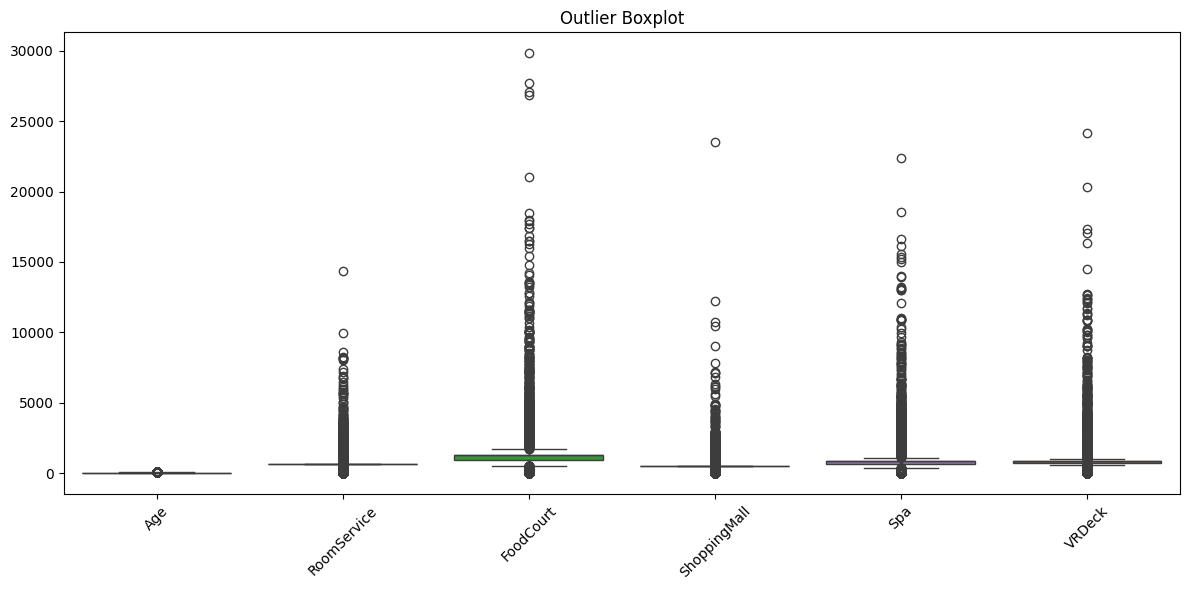

In [477]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[fitur_numerik])
plt.xticks(rotation=45)
plt.title("Outlier Boxplot")
plt.tight_layout()
plt.show()

**b. Outlier Handling**

Lakukan outlier handling dengan cara mengubah nilai outlier menjadi mean fitur/kolom. Suatu data dikatakan outlier jika nilainya berada di luar batas bawah (lower_bound) atau batas atas (upper_bound).

In [478]:
def handle_outliers(df):
    for column in fitur_numerik:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (1.5 * IQR)   # Batas bawah, gunakan rumus di modul
        upper_bound = Q3 + (1.5 * IQR)   # Batas atas, gunakan rumus di modul

        # Ganti nilai outlier dengan mean dari kolom
        mean_value = df[column].mean()
        df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), mean_value, df[column]) # Gunakan properti np.where

        mean_value = df[column].mean()
    return df

In [479]:
df = handle_outliers(df)

In [480]:
df[fitur_numerik].describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.000000,8.693000e+03,8693.000000,8.693000e+03,8693.000000,8693.000000
mean,28.735439,6.516324e+02,1244.685126,5.086584e+02,815.673486,856.184287
std,12.667913,9.253077e-14,140.445716,1.969189e-13,73.560360,34.322139
min,1.000000,6.516324e+02,508.000000,5.086584e+02,352.000000,581.000000
25%,20.000000,6.516324e+02,1276.436477,5.086584e+02,831.070621,861.392027
50%,28.000000,6.516324e+02,1276.436477,5.086584e+02,831.070621,861.392027
75%,36.000000,6.516324e+02,1276.436477,5.086584e+02,831.070621,861.392027
max,62.000000,6.516324e+02,1740.000000,5.086584e+02,1114.000000,1030.000000


**c. Cek Hasil penanganan**

Cek hasil penanganan outlier dengan membandingkan boxplot data yang telah diatasi dengan boxplot sebelumnya

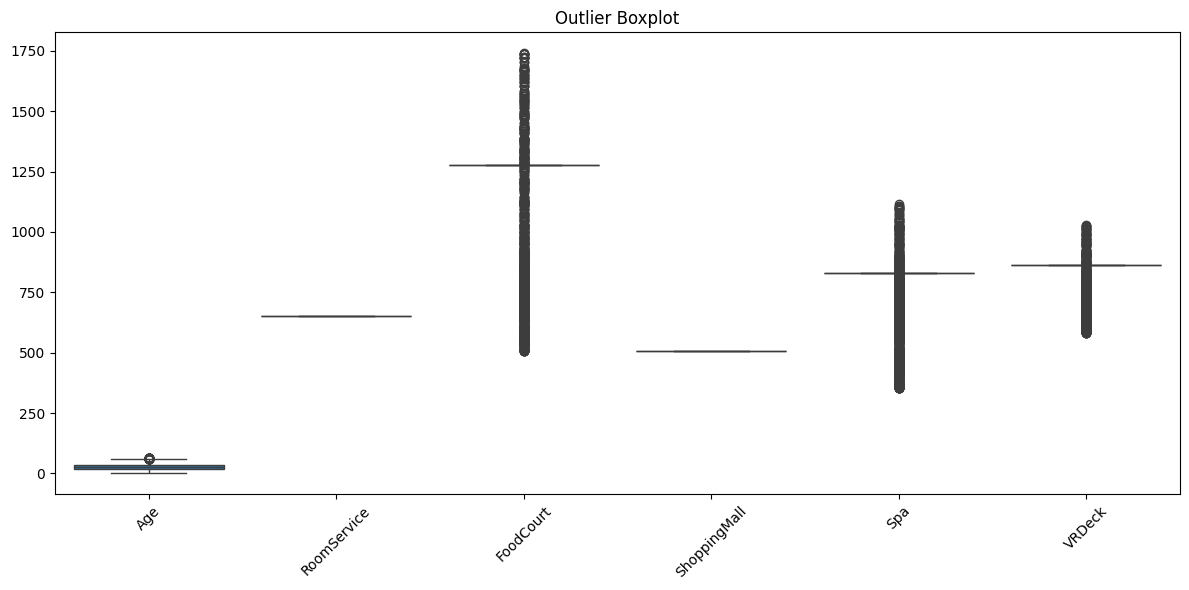

In [481]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[fitur_numerik])
plt.xticks(rotation=45)
plt.title("Outlier Boxplot")
plt.tight_layout()
plt.show()

## **6. Normalisasi Data**

**Lakukan normalisasi data fitur numerik**

**a. Cetak rentang masing-masing kolom**

In [482]:
def cetak_rentang (df_input):
    list_fitur = df_input.columns[:-1]
    for fitur in list_fitur:
        max = df_input[fitur].max()
        min = df_input[fitur].min()
    print("Rentang fitur",fitur,max-min)

In [483]:
df.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported'],
      dtype='object')

In [484]:
# Apply cetak_rentang
def cetak_rentang(df_input):
    for column in df_input.columns:
        min_val = df_input[column].min()
        max_val = df_input[column].max()
        rentang = max_val - min_val
        print(f"Rentang nilai {column}: {rentang}")

for fitur in fitur_numerik:
        cetak_rentang(df[[fitur]])


Rentang nilai Age: 61.0
Rentang nilai RoomService: 1.1368683772161603e-13
Rentang nilai FoodCourt: 1232.0
Rentang nilai ShoppingMall: 1.1368683772161603e-13
Rentang nilai Spa: 762.0
Rentang nilai VRDeck: 449.0


**b. Cek statistik sebelum normalisasi**

In [486]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.000000,8.693000e+03,8693.000000,8.693000e+03,8693.000000,8693.000000
mean,28.735439,6.516324e+02,1244.685126,5.086584e+02,815.673486,856.184287
std,12.667913,9.253077e-14,140.445716,1.969189e-13,73.560360,34.322139
min,1.000000,6.516324e+02,508.000000,5.086584e+02,352.000000,581.000000
25%,20.000000,6.516324e+02,1276.436477,5.086584e+02,831.070621,861.392027
50%,28.000000,6.516324e+02,1276.436477,5.086584e+02,831.070621,861.392027
75%,36.000000,6.516324e+02,1276.436477,5.086584e+02,831.070621,861.392027
max,62.000000,6.516324e+02,1740.000000,5.086584e+02,1114.000000,1030.000000


**c. Normalisasi MinMax**

Buat fungsi normalisasi dengan metode minmax

In [487]:
def minmax(df_input):
    for fitur in fitur_numerik:
        max = df_input[fitur].max()
        min = df_input[fitur].min()
        df_input[fitur] = (df_input[fitur] - min) / (max - min)
    return df_input

In [488]:
# Apply fungsi normalisasi
df_normal = minmax(df)


In [489]:
df_normal.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,0.454679,0.337628,0.597959,0.666628,0.608495,0.612883
std,0.207671,0.472928,0.113998,0.471445,0.096536,0.076441
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.311475,0.000000,0.623731,0.000000,0.628702,0.624481
50%,0.442623,0.000000,0.623731,1.000000,0.628702,0.624481
75%,0.573770,1.000000,0.623731,1.000000,0.628702,0.624481
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


***Pertanyaan***

Cetak rentang dan statistik kolom setelah normalisasi, lalu bandingkan dengan saat sebelum dilakukan normalisasi. Apa perbedaannya dan jelaskan secara singkat!

In [490]:
cetak_rentang(df[fitur_numerik])

Rentang nilai Age: 1.0
Rentang nilai RoomService: 1.0
Rentang nilai FoodCourt: 1.0
Rentang nilai ShoppingMall: 1.0
Rentang nilai Spa: 1.0
Rentang nilai VRDeck: 1.0


In [491]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,0.454679,0.337628,0.597959,0.666628,0.608495,0.612883
std,0.207671,0.472928,0.113998,0.471445,0.096536,0.076441
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.311475,0.000000,0.623731,0.000000,0.628702,0.624481
50%,0.442623,0.000000,0.623731,1.000000,0.628702,0.624481
75%,0.573770,1.000000,0.623731,1.000000,0.628702,0.624481
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [492]:
cetak_rentang(df_normal[fitur_numerik])

Rentang nilai Age: 1.0
Rentang nilai RoomService: 1.0
Rentang nilai FoodCourt: 1.0
Rentang nilai ShoppingMall: 1.0
Rentang nilai Spa: 1.0
Rentang nilai VRDeck: 1.0


In [493]:
df_normal.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,0.454679,0.337628,0.597959,0.666628,0.608495,0.612883
std,0.207671,0.472928,0.113998,0.471445,0.096536,0.076441
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.311475,0.000000,0.623731,0.000000,0.628702,0.624481
50%,0.442623,0.000000,0.623731,1.000000,0.628702,0.624481
75%,0.573770,1.000000,0.623731,1.000000,0.628702,0.624481
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Jawaban: Perbedaan utama setelah normalisasi adalah rentang nilai untuk sebagian besar kolom menjadi 1.0, membuatnya berada dalam rentang 0-1. Jadi, normalisasi membantu menghilangkan perbedaan skala yang signifikan antar fitur, sehingga semua fitur memiliki bobot yang setara dalam analisis selanjutnya.

## **7. Label Encoding**



**a. Lakukan label encoding untuk fitur/kolom kategorikal!**

In [494]:
fitur_kategorikal

['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

In [495]:
def label_encoding(x):
    label_map = {
        'HomePlanet': {'Europa': 0, 'Earth': 1, 'Mars': 2},
        'CryoSleep': {'False': 0, 'True': 1},
        'Destination': {'TRAPPIST-1e': 0, 'PSO J318.5-22': 1, '55 Cancri e': 2},
        'VIP': {'False': 0, 'True': 1}
    }
    return x.map(label_map.get(x.name, {})).fillna(-1).astype(int)

**b. Ubah kolom target, yang awalnya boolean menjadi integer**

In [496]:
fitur_encoding = df[fitur_kategorikal].apply(label_encoding)
df[fitur_kategorikal] = fitur_encoding

df['Transported'] = df['Transported'].astype(int)
df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,0,-1,0,0.622951,-1,0.0,0.623731,1.0,0.628702,0.624481,0
1,1,-1,0,0.377049,-1,1.0,0.623731,0.0,0.258530,0.624481,1
2,0,-1,0,0.934426,-1,1.0,0.623731,1.0,0.628702,0.624481,0
3,0,-1,0,0.524590,-1,0.0,0.629058,0.0,0.628702,0.624481,0
4,1,-1,0,0.245902,-1,1.0,0.623731,0.0,0.279528,0.624481,1


***Pertanyaan***

Mengapa label encoding penting?

Jawaban: Label encoding penting karena komputer tidak bisa memproses data yang berupa string, jadi kita perlu mengubahnya terlebih dahulu ke dalam bentuk angka.

## **8. Cek Hasil Preprocessing**

Cetak dataframe hasil preprocessing

In [497]:
df_normal

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,0,-1,0,0.622951,-1,0.0,0.623731,1.0,0.628702,0.624481,0
1,1,-1,0,0.377049,-1,1.0,0.623731,0.0,0.258530,0.624481,1
2,0,-1,0,0.934426,-1,1.0,0.623731,1.0,0.628702,0.624481,0
3,0,-1,0,0.524590,-1,0.0,0.629058,0.0,0.628702,0.624481,0
4,1,-1,0,0.245902,-1,1.0,0.623731,0.0,0.279528,0.624481,1
...,...,...,...,...,...,...,...,...,...,...,...
8688,0,-1,2,0.655738,-1,0.0,0.623731,1.0,0.628702,0.624481,0
8689,1,-1,1,0.278689,-1,0.0,0.623731,1.0,0.628702,0.624481,0
8690,1,-1,0,0.409836,-1,0.0,0.623731,0.0,0.628702,0.624481,1
8691,0,-1,2,0.508197,-1,0.0,0.439123,1.0,0.001312,0.624481,0


***Pertanyaan***

Menurutmu, hal apa lagi yang bisa dilakukan dalam pemrosesan awal data selain yang di atas, jika melihat karakteristik dataset?

Jawaban: Menurut saya, hal lain yang bisa dilakukan salah satunya adalah mencoba one-hot encoding untuk fitur-fitur yang bersifat nominal (HomePlanet, CryoSleep, Destination misalnya). Lalu juga bisa melakukan log transform untuk mengatasi skewness (Age menurut saya cukup skewed datanya). Dan mungkin diperlukan juga untuk melakukan pengecekan terhadap multikolinearitas antar fitur. Kita juga bisa mencoba melakukan penggabungan fitur (feature engineering) untuk menciptakan fitur baru yang mungkin lebih informatif (misalnya fitur destinasi yang sering dikunjungi VIP)